# Notebook 06 — Analyse de la progression

## Objectif

L'objectif de ce notebook est d'analyser l'évolution des performances
des patients au cours de leurs séances de rééducation.

Nous allons étudier :

- la progression entre deux séances consécutives ;
- les améliorations et diminutions ;
- la progression moyenne par patient ;
- la stabilité des performances ;
- la progression par exercice, jeu et niveau ;
- les variations extrêmes ;
- les tendances individuelles ;
- la classification de l'évolution des patients.

Ces analyses permettront de préparer les indicateurs nécessaires
au dashboard destiné au thérapeute.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROCESSED_PATH = "../data/processed/"

In [3]:
session_analysis = pd.read_csv(
    PROCESSED_PATH + "session_analysis.csv"
)

In [4]:
print("Dimensions :", session_analysis.shape)

print("\nColonnes :")
print(session_analysis.columns.tolist())

print("\nPremières lignes :")
display(session_analysis.head())

Dimensions : (500, 36)

Colonnes :
['id_assignment', 'patient_id', 'exercise_id', 'start_level_id', 'current_level_id', 'assigned_by', 'assigned_at', 'is_active', 'id_patient', 'first_name', 'last_name', 'date_of_birth', 'id_exercise', 'game_id', 'name', 'description', 'id_game', 'name_game', 'body_part', 'description_game', 'id_current_level', 'level_number', 'title', 'target_angle', 'required_score', 'required_progression', 'id_session', 'patient_exercise_id', 'exercise_level_id', 'session_date', 'duration', 'score', 'session_id', 'repetitions', 'success_rate', 'progression']

Premières lignes :


,id_assignment,patient_id,exercise_id,start_level_id,current_level_id,assigned_by,assigned_at,is_active,id_patient,first_name,...,id_session,patient_exercise_id,exercise_level_id,session_date,duration,score,session_id,repetitions,success_rate,progression
0,1,1,7,20,21,3,2026-04-26 11:12:54,True,1,Yasmine,...,1,1,20,2026-04-30 15:50:31,4,60.6,1,9,60.2,NaN
1,1,1,7,20,21,3,2026-04-26 11:12:54,True,1,Yasmine,...,2,1,20,2026-05-04 15:00:15,8,52.5,2,9,52.7,-13.37
2,1,1,7,20,21,3,2026-04-26 11:12:54,True,1,Yasmine,...,4,1,20,2026-05-07 15:00:09,5,63.8,4,10,68.7,21.52
3,1,1,7,20,21,3,2026-04-26 11:12:54,True,1,Yasmine,...,6,1,20,2026-05-12 15:10:22,4,60.3,6,6,59.0,-5.49
4,1,1,7,20,21,3,2026-04-26 11:12:54,True,1,Yasmine,...,8,1,20,2026-05-16 10:45:20,9,62.7,8,11,70.3,3.98


In [5]:
session_analysis["session_date"] = pd.to_datetime(
    session_analysis["session_date"]
)

In [6]:
print(session_analysis["session_date"].dtype)

datetime64[ns]


In [7]:
session_analysis = session_analysis.sort_values(
    by=["patient_id", "exercise_id", "session_date"]
).reset_index(drop=True)

In [8]:
display(
    session_analysis[
        ["patient_id", "exercise_id", "session_date", "score"]
    ].head(20)
)

,patient_id,exercise_id,session_date,score
0,1,7,2026-04-30 15:50:31,60.6
1,1,7,2026-05-04 15:00:15,52.5
2,1,7,2026-05-07 15:00:09,63.8
3,1,7,2026-05-12 15:10:22,60.3
4,1,7,2026-05-16 10:45:20,62.7
5,1,7,2026-05-21 15:40:50,61.0
6,1,7,2026-05-25 15:20:30,68.5
7,1,7,2026-05-30 10:15:13,68.9
8,1,7,2026-06-17 15:40:41,65.4
9,1,7,2026-06-20 10:30:31,60.3


In [9]:
chronology_check = (
    session_analysis
    .groupby(["patient_id", "exercise_id"])["session_date"]
    .diff()
)

print("Nombre de dates non chronologiques :",
      (chronology_check < pd.Timedelta(0)).sum())

Nombre de dates non chronologiques : 0


In [10]:
session_analysis["previous_score"] = (
    session_analysis
    .groupby(["patient_id", "exercise_id"])["score"]
    .shift(1)
)

In [11]:
session_analysis["calculated_progression"] = np.where(
    session_analysis["previous_score"].notna(),
    (
        (session_analysis["score"] - session_analysis["previous_score"])
        / session_analysis["previous_score"]
    ) * 100,
    np.nan
)

In [12]:
display(
    session_analysis[
        [
            "patient_id",
            "exercise_id",
            "session_date",
            "previous_score",
            "score",
            "progression",
            "calculated_progression"
        ]
    ].head(20)
)

,patient_id,exercise_id,session_date,previous_score,score,progression,calculated_progression
0,1,7,2026-04-30 15:50:31,NaN,60.6,NaN,NaN
1,1,7,2026-05-04 15:00:15,60.6,52.5,-13.37,-13.366337
2,1,7,2026-05-07 15:00:09,52.5,63.8,21.52,21.523810
3,1,7,2026-05-12 15:10:22,63.8,60.3,-5.49,-5.485893
4,1,7,2026-05-16 10:45:20,60.3,62.7,3.98,3.980100
5,1,7,2026-05-21 15:40:50,62.7,61.0,-2.71,-2.711324
6,1,7,2026-05-25 15:20:30,61.0,68.5,12.30,12.295082
7,1,7,2026-05-30 10:15:13,68.5,68.9,0.58,0.583942
8,1,7,2026-06-17 15:40:41,68.9,65.4,-5.08,-5.079826
9,1,7,2026-06-20 10:30:31,65.4,60.3,-7.80,-7.798165


In [13]:
progression_difference = (
    session_analysis["progression"]
    - session_analysis["calculated_progression"]
).abs()

print(
    "Différence maximale :",
    progression_difference.max()
)

Différence maximale : 0.0049999999999919


In [14]:
first_sessions = session_analysis[
    session_analysis["previous_score"].isna()
]

print(
    "Premières séances sans score précédent :",
    len(first_sessions)
)

print(
    "Progressions renseignées sur ces séances :",
    first_sessions["progression"].notna().sum()
)

Premières séances sans score précédent : 43
Progressions renseignées sur ces séances : 0


In [15]:
progression_stats = (
    session_analysis["progression"]
    .describe()
)

display(progression_stats)

count    457.000000
mean       3.003961
std       15.304562
min      -49.860000
25%       -5.110000
50%        1.760000
75%       10.150000
max      107.020000
Name: progression, dtype: float64

In [16]:
mean_progression = session_analysis["progression"].mean()
median_progression = session_analysis["progression"].median()

print(f"Progression moyenne : {mean_progression:.2f}%")
print(f"Progression médiane : {median_progression:.2f}%")

Progression moyenne : 3.00%
Progression médiane : 1.76%


In [17]:
def classify_progression(value):
    if pd.isna(value):
        return "Première séance"
    elif value > 0:
        return "Amélioration"
    elif value < 0:
        return "Diminution"
    else:
        return "Stable"


session_analysis["progression_status"] = (
    session_analysis["progression"]
    .apply(classify_progression)
)

In [18]:
print(
    session_analysis["progression_status"]
    .value_counts()
)

progression_status
Amélioration       260
Diminution         196
Première séance     43
Stable               1
Name: count, dtype: int64


In [19]:
progression_distribution = (
    session_analysis["progression_status"]
    .value_counts(normalize=True)
    * 100
)

display(
    progression_distribution.round(2)
)

progression_status
Amélioration       52.0
Diminution         39.2
Première séance     8.6
Stable              0.2
Name: proportion, dtype: float64

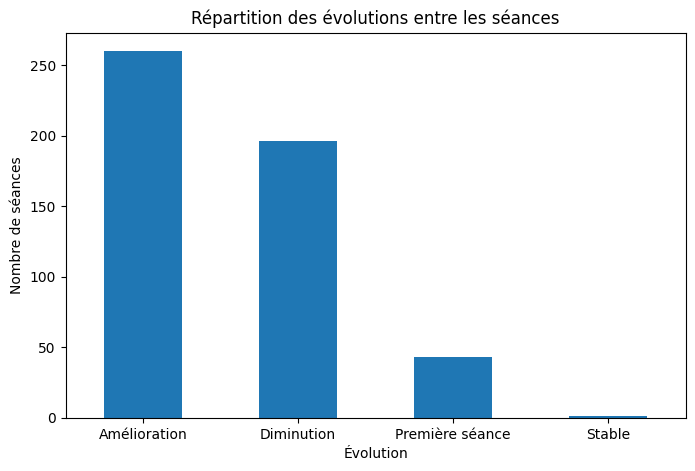

In [20]:
status_counts = (
    session_analysis["progression_status"]
    .value_counts()
)

status_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Répartition des évolutions entre les séances")
plt.xlabel("Évolution")
plt.ylabel("Nombre de séances")
plt.xticks(rotation=0)
plt.show()

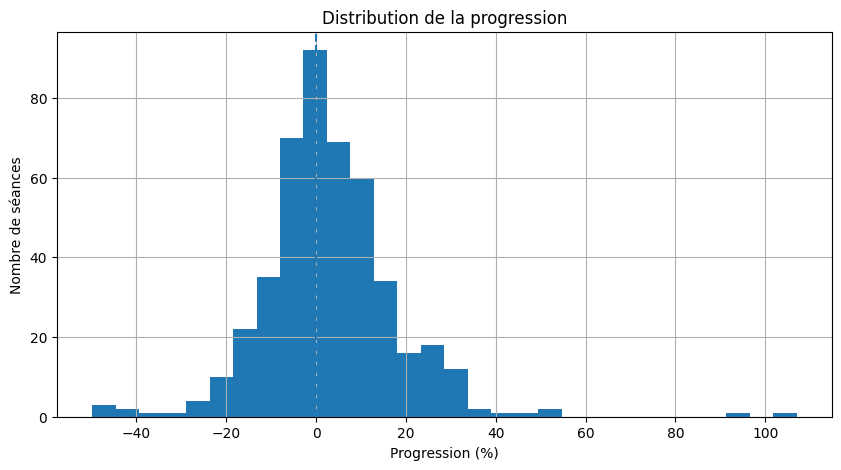

In [21]:
plt.figure(figsize=(10, 5))

session_analysis["progression"].dropna().hist(
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution de la progression")
plt.xlabel("Progression (%)")
plt.ylabel("Nombre de séances")

plt.show()

In [22]:
patient_progression = (
    session_analysis
    .groupby(["patient_id", "first_name", "last_name"])
    .agg(
        sessions_with_progression=("progression", "count"),
        mean_progression=("progression", "mean"),
        median_progression=("progression", "median"),
        max_progression=("progression", "max"),
        min_progression=("progression", "min"),
        std_progression=("progression", "std")
    )
    .reset_index()
)

In [23]:
display(
    patient_progression.sort_values(
        "mean_progression",
        ascending=False
    )
)

,patient_id,first_name,last_name,sessions_with_progression,mean_progression,median_progression,max_progression,min_progression,std_progression
17,18,Lina,Chaouch,27,8.828889,8.000,107.02,-49.86,39.925818
12,13,Nour,Zouari,14,5.643571,8.275,31.60,-34.47,21.644962
18,19,Mohamed,Slimani,11,4.930909,3.820,21.16,-9.23,7.891120
4,5,Zied,Gharbi,39,4.317949,3.580,29.74,-18.71,11.620415
6,7,Yassine,Sassi,29,3.481034,3.150,27.73,-14.90,12.028851
0,1,Yasmine,Bouzid,24,3.241250,3.690,21.52,-14.53,10.743028
5,6,Eya,Haddad,62,3.056774,1.335,30.53,-20.93,10.475867
9,10,Maya,Trabelsi,28,3.005000,1.955,28.02,-16.71,10.265696
13,14,Ilyes,Belhaj,18,2.633889,2.065,53.01,-43.55,26.381936
7,8,Hiba,Khelifi,12,2.631667,3.370,14.08,-9.06,6.587797


In [24]:
print(
    "Nombre de patients :",
    patient_progression["patient_id"].nunique()
)

Nombre de patients : 20


In [25]:
patient_improvement = (
    session_analysis
    .groupby(["patient_id", "first_name", "last_name"])
    .agg(
        sessions_with_progression=(
            "progression",
            lambda x: x.notna().sum()
        ),
        improved_sessions=(
            "progression",
            lambda x: (x > 0).sum()
        ),
        declined_sessions=(
            "progression",
            lambda x: (x < 0).sum()
        )
    )
    .reset_index()
)

patient_improvement["improvement_rate"] = (
    patient_improvement["improved_sessions"]
    / patient_improvement["sessions_with_progression"]
    * 100
)

In [26]:
display(
    patient_improvement.sort_values(
        "improvement_rate",
        ascending=False
    )
)

,patient_id,first_name,last_name,sessions_with_progression,improved_sessions,declined_sessions,improvement_rate
18,19,Mohamed,Slimani,11,9,2,81.818182
4,5,Zied,Gharbi,39,26,13,66.666667
7,8,Hiba,Khelifi,12,8,4,66.666667
9,10,Maya,Trabelsi,28,18,10,64.285714
16,17,Skander,Karoui,14,9,5,64.285714
12,13,Nour,Zouari,14,9,5,64.285714
17,18,Lina,Chaouch,27,17,10,62.962963
10,11,Sirine,Ben Salah,24,15,9,62.500000
0,1,Yasmine,Bouzid,24,14,10,58.333333
5,6,Eya,Haddad,62,36,26,58.064516


In [27]:
positive_progression = patient_progression[
    patient_progression["mean_progression"] > 0
].copy()

print(
    "Patients avec progression moyenne positive :",
    len(positive_progression)
)

display(
    positive_progression[
        [
            "first_name",
            "last_name",
            "mean_progression"
        ]
    ].sort_values(
        "mean_progression",
        ascending=False
    )
)

Patients avec progression moyenne positive : 20


,first_name,last_name,mean_progression
17,Lina,Chaouch,8.828889
12,Nour,Zouari,5.643571
18,Mohamed,Slimani,4.930909
4,Zied,Gharbi,4.317949
6,Yassine,Sassi,3.481034
0,Yasmine,Bouzid,3.241250
5,Eya,Haddad,3.056774
9,Maya,Trabelsi,3.005000
13,Ilyes,Belhaj,2.633889
7,Hiba,Khelifi,2.631667


In [28]:
low_progression = patient_progression[
    patient_progression["mean_progression"] < 1
].copy()

display(
    low_progression[
        [
            "first_name",
            "last_name",
            "mean_progression",
            "sessions_with_progression"
        ]
    ].sort_values("mean_progression")
)

,first_name,last_name,mean_progression,sessions_with_progression
14,Aymen,Nasri,0.371538,13
19,Omar,Dridi,0.476818,22
11,Rim,Ayari,0.492500,8


In [29]:
exercise_progression = (
    session_analysis
    .groupby(["exercise_id", "name"])
    .agg(
        sessions=("progression", "count"),
        mean_progression=("progression", "mean"),
        median_progression=("progression", "median"),
        std_progression=("progression", "std"),
        max_progression=("progression", "max"),
        min_progression=("progression", "min")
    )
    .reset_index()
)

In [30]:
display(
    exercise_progression.sort_values(
        "mean_progression",
        ascending=False
    )
)

,exercise_id,name,sessions,mean_progression,median_progression,std_progression,max_progression,min_progression
7,8,Forearm Rotation,97,4.445773,3.400,18.794066,107.02,-49.48
3,4,Seated Knee Extension,51,3.790392,1.000,21.794803,95.11,-49.86
1,2,Lateral Arm Raise,28,3.226429,3.495,10.213130,23.82,-20.93
4,5,Mini Squat,57,3.144561,2.110,11.322339,32.78,-18.31
0,1,Forward Arm Raise,52,2.361154,-0.695,12.015311,30.53,-17.58
5,6,Step Up,73,2.164795,1.030,10.053172,32.64,-23.86
6,7,Wrist Flexion and Extension,84,2.114643,0.905,16.472876,53.01,-49.66
2,3,Overhead Reach,15,1.349333,0.540,10.609349,20.87,-20.35


In [31]:
game_progression = (
    session_analysis
    .groupby(["game_id", "name_game"])
    .agg(
        sessions=("progression", "count"),
        mean_progression=("progression", "mean"),
        median_progression=("progression", "median"),
        std_progression=("progression", "std")
    )
    .reset_index()
)

In [32]:
display(
    game_progression.sort_values(
        "mean_progression",
        ascending=False
    )
)

,game_id,name_game,sessions,mean_progression,median_progression,std_progression
2,3,Wrist Wizard,181,3.363923,2.68,17.744478
1,2,Step Quest,181,2.931381,1.64,14.584906
0,1,Bubble Reach,95,2.456421,1.83,11.199517


In [33]:
level_progression = (
    session_analysis
    .groupby("level_number")
    .agg(
        sessions=("progression", "count"),
        mean_progression=("progression", "mean"),
        median_progression=("progression", "median"),
        std_progression=("progression", "std"),
        max_progression=("progression", "max"),
        min_progression=("progression", "min")
    )
    .reset_index()
)

In [34]:
display(level_progression)

,level_number,sessions,mean_progression,median_progression,std_progression,max_progression,min_progression
0,1,58,1.717414,0.445,11.226654,37.40,-25.09
1,2,226,3.520398,2.700,18.169084,107.02,-49.86
2,3,173,2.760636,1.500,12.099880,53.01,-43.55


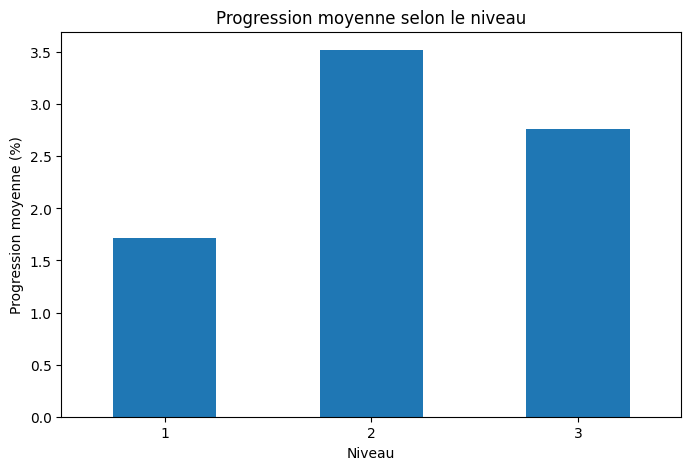

In [35]:
level_progression.plot(
    x="level_number",
    y="mean_progression",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Progression moyenne selon le niveau")
plt.xlabel("Niveau")
plt.ylabel("Progression moyenne (%)")
plt.xticks(rotation=0)

plt.show()

In [36]:
patient_id_example = 1

patient_data = session_analysis[
    session_analysis["patient_id"] == patient_id_example
].sort_values("session_date")

display(
    patient_data[
        [
            "session_date",
            "name",
            "level_number",
            "score",
            "success_rate",
            "progression"
        ]
    ]
)

,session_date,name,level_number,score,success_rate,progression
0,2026-04-30 15:50:31,Wrist Flexion and Extension,3,60.6,60.2,NaN
1,2026-05-04 15:00:15,Wrist Flexion and Extension,3,52.5,52.7,-13.37
13,2026-05-05 15:20:38,Forearm Rotation,2,47.1,52.7,NaN
2,2026-05-07 15:00:09,Wrist Flexion and Extension,3,63.8,68.7,21.52
14,2026-05-08 15:20:48,Forearm Rotation,2,48.7,61.3,3.40
3,2026-05-12 15:10:22,Wrist Flexion and Extension,3,60.3,59.0,-5.49
15,2026-05-12 15:55:04,Forearm Rotation,2,57.5,62.4,18.07
4,2026-05-16 10:45:20,Wrist Flexion and Extension,3,62.7,70.3,3.98
16,2026-05-18 15:00:36,Forearm Rotation,2,52.9,55.8,-8.00
5,2026-05-21 15:40:50,Wrist Flexion and Extension,3,61.0,60.4,-2.71


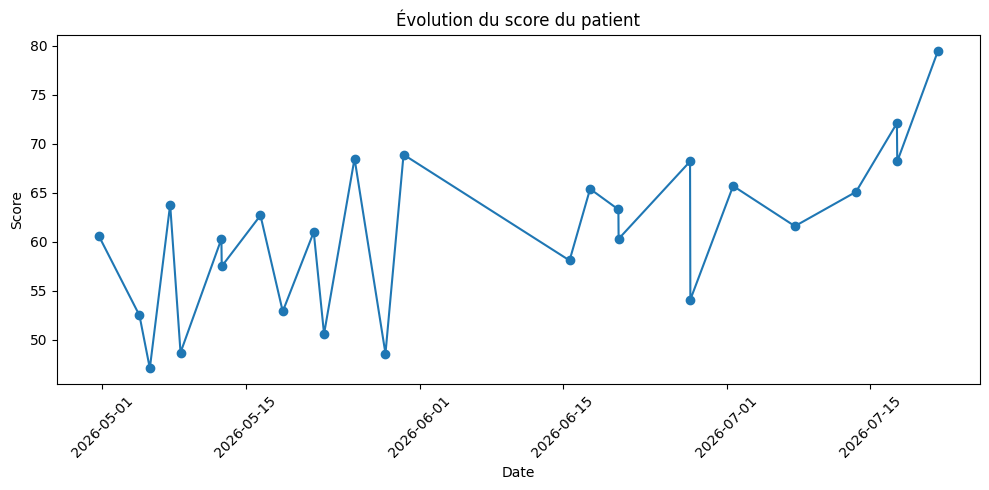

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    patient_data["session_date"],
    patient_data["score"],
    marker="o"
)

plt.title("Évolution du score du patient")
plt.xlabel("Date")
plt.ylabel("Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

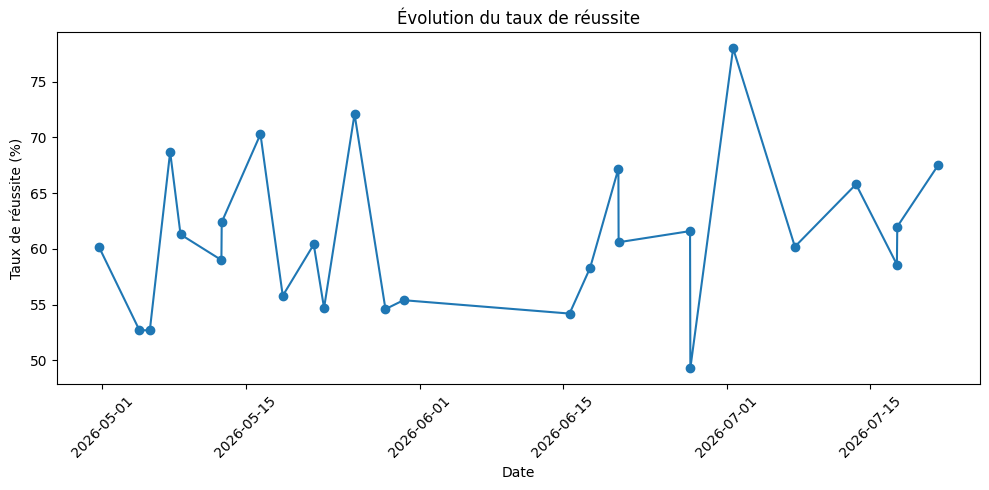

In [38]:
plt.figure(figsize=(10, 5))

plt.plot(
    patient_data["session_date"],
    patient_data["success_rate"],
    marker="o"
)

plt.title("Évolution du taux de réussite")
plt.xlabel("Date")
plt.ylabel("Taux de réussite (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

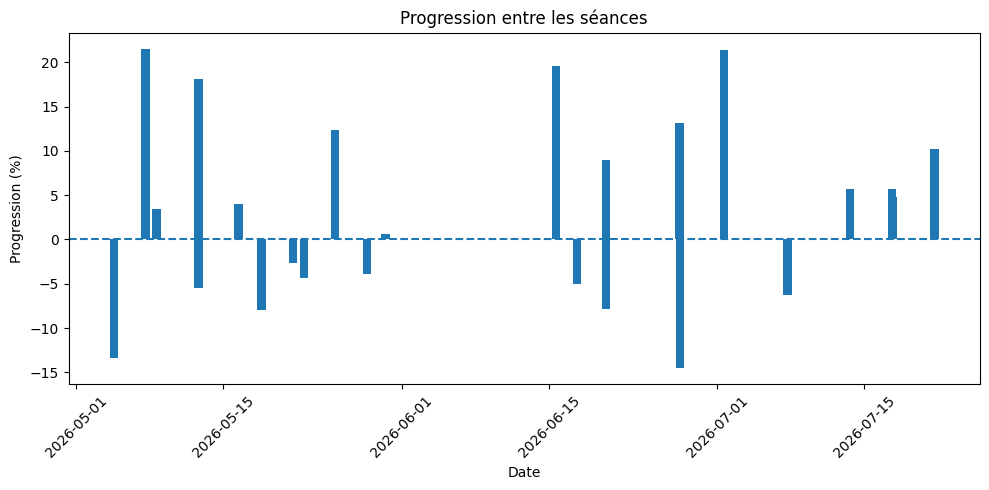

In [39]:
progression_data = patient_data.dropna(
    subset=["progression"]
)

plt.figure(figsize=(10, 5))

plt.bar(
    progression_data["session_date"],
    progression_data["progression"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Progression entre les séances")
plt.xlabel("Date")
plt.ylabel("Progression (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [40]:
extreme_progressions = session_analysis[
    session_analysis["progression"].abs() > 30
].copy()

In [41]:
display(
    extreme_progressions[
        [
            "patient_id",
            "first_name",
            "last_name",
            "exercise_id",
            "name",
            "session_date",
            "previous_score",
            "score",
            "progression"
        ]
    ].sort_values(
        "progression",
        ascending=False
    )
)

,patient_id,first_name,last_name,exercise_id,name,session_date,previous_score,score,progression
459,18,Lina,Chaouch,8,Forearm Rotation,2026-08-07 16:10:48,24.2,50.1,107.02
438,18,Lina,Chaouch,4,Seated Knee Extension,2026-08-12 16:00:50,34.8,67.9,95.11
373,14,Ilyes,Belhaj,7,Wrist Flexion and Extension,2026-08-29 10:45:49,51.5,78.8,53.01
436,18,Lina,Chaouch,4,Seated Knee Extension,2026-08-05 16:30:18,45.5,69.4,52.53
455,18,Lina,Chaouch,8,Forearm Rotation,2026-07-11 10:30:29,36.0,53.5,48.61
443,18,Lina,Chaouch,4,Seated Knee Extension,2026-09-01 16:10:55,35.8,50.0,39.66
97,4,Malek,Hamdi,8,Forearm Rotation,2026-07-22 17:40:43,39.3,54.0,37.40
378,14,Ilyes,Belhaj,8,Forearm Rotation,2026-08-15 10:30:14,39.7,54.5,37.28
414,16,Rayan,Mansouri,5,Mini Squat,2026-09-10 16:10:04,42.4,56.3,32.78
76,3,Fatma,Tlili,8,Forearm Rotation,2026-06-12 15:10:00,41.8,55.5,32.78


In [42]:
print(
    "Nombre de variations supérieures à +30% ou inférieures à -30% :",
    len(extreme_progressions)
)

Nombre de variations supérieures à +30% ou inférieures à -30% : 23


In [43]:
top_progressions = (
    session_analysis
    .dropna(subset=["progression"])
    .nlargest(10, "progression")
)

display(
    top_progressions[
        [
            "patient_id",
            "first_name",
            "last_name",
            "name",
            "session_date",
            "previous_score",
            "score",
            "progression"
        ]
    ]
)

,patient_id,first_name,last_name,name,session_date,previous_score,score,progression
459,18,Lina,Chaouch,Forearm Rotation,2026-08-07 16:10:48,24.2,50.1,107.02
438,18,Lina,Chaouch,Seated Knee Extension,2026-08-12 16:00:50,34.8,67.9,95.11
373,14,Ilyes,Belhaj,Wrist Flexion and Extension,2026-08-29 10:45:49,51.5,78.8,53.01
436,18,Lina,Chaouch,Seated Knee Extension,2026-08-05 16:30:18,45.5,69.4,52.53
455,18,Lina,Chaouch,Forearm Rotation,2026-07-11 10:30:29,36.0,53.5,48.61
443,18,Lina,Chaouch,Seated Knee Extension,2026-09-01 16:10:55,35.8,50.0,39.66
97,4,Malek,Hamdi,Forearm Rotation,2026-07-22 17:40:43,39.3,54.0,37.40
378,14,Ilyes,Belhaj,Forearm Rotation,2026-08-15 10:30:14,39.7,54.5,37.28
76,3,Fatma,Tlili,Forearm Rotation,2026-06-12 15:10:00,41.8,55.5,32.78
414,16,Rayan,Mansouri,Mini Squat,2026-09-10 16:10:04,42.4,56.3,32.78


In [44]:
lowest_progressions = (
    session_analysis
    .dropna(subset=["progression"])
    .nsmallest(10, "progression")
)

display(
    lowest_progressions[
        [
            "patient_id",
            "first_name",
            "last_name",
            "name",
            "session_date",
            "previous_score",
            "score",
            "progression"
        ]
    ]
)

,patient_id,first_name,last_name,name,session_date,previous_score,score,progression
437,18,Lina,Chaouch,Seated Knee Extension,2026-08-08 11:15:22,69.4,34.8,-49.86
449,18,Lina,Chaouch,Wrist Flexion and Extension,2026-08-28 16:20:33,74.1,37.3,-49.66
458,18,Lina,Chaouch,Forearm Rotation,2026-08-04 16:50:35,47.9,24.2,-49.48
370,14,Ilyes,Belhaj,Wrist Flexion and Extension,2026-08-03 15:00:03,76.7,43.3,-43.55
441,18,Lina,Chaouch,Seated Knee Extension,2026-08-22 11:00:19,59.3,34.5,-41.82
361,13,Nour,Zouari,Forearm Rotation,2026-08-15 10:45:32,67.6,44.3,-34.47
439,18,Lina,Chaouch,Seated Knee Extension,2026-08-15 10:45:06,67.9,44.8,-34.02
367,14,Ilyes,Belhaj,Wrist Flexion and Extension,2026-07-22 15:40:47,85.1,60.7,-28.67
356,13,Nour,Zouari,Wrist Flexion and Extension,2026-08-20 15:00:58,63.5,46.9,-26.14
75,3,Fatma,Tlili,Forearm Rotation,2026-06-10 15:50:05,55.8,41.8,-25.09


In [45]:
stability_analysis = (
    session_analysis
    .groupby(["patient_id", "first_name", "last_name"])
    .agg(
        mean_progression=("progression", "mean"),
        std_progression=("progression", "std"),
        min_progression=("progression", "min"),
        max_progression=("progression", "max")
    )
    .reset_index()
)

In [46]:
display(
    stability_analysis.sort_values(
        "std_progression"
    )
)

,patient_id,first_name,last_name,mean_progression,std_progression,min_progression,max_progression
14,15,Aymen,Nasri,0.371538,6.399864,-7.59,12.08
7,8,Hiba,Khelifi,2.631667,6.587797,-9.06,14.08
19,20,Omar,Dridi,0.476818,6.996763,-14.17,15.66
18,19,Mohamed,Slimani,4.930909,7.891120,-9.23,21.16
8,9,Adam,Mejri,2.558261,8.085024,-10.73,17.69
10,11,Sirine,Ben Salah,1.307917,10.107611,-18.31,32.64
9,10,Maya,Trabelsi,3.005000,10.265696,-16.71,28.02
5,6,Eya,Haddad,3.056774,10.475867,-20.93,30.53
0,1,Yasmine,Bouzid,3.241250,10.743028,-14.53,21.52
16,17,Skander,Karoui,2.381429,11.467947,-20.35,20.87


In [47]:
def classify_patient_progression(value):
    if value >= 5:
        return "Progression forte"
    elif value >= 2:
        return "Progression modérée"
    else:
        return "Progression faible"


patient_progression["progression_category"] = (
    patient_progression["mean_progression"]
    .apply(classify_patient_progression)
)

In [48]:
print(
    patient_progression["progression_category"]
    .value_counts()
)

progression_category
Progression modérée    11
Progression faible      7
Progression forte       2
Name: count, dtype: int64


In [49]:
patient_progression_dashboard = (
    patient_progression
    .merge(
        patient_improvement[
            [
                "patient_id",
                "improved_sessions",
                "declined_sessions",
                "improvement_rate"
            ]
        ],
        on="patient_id",
        how="left"
    )
)

In [50]:
display(
    patient_progression_dashboard
)

,patient_id,first_name,last_name,sessions_with_progression,mean_progression,median_progression,max_progression,min_progression,std_progression,progression_category,improved_sessions,declined_sessions,improvement_rate
0,1,Yasmine,Bouzid,24,3.241250,3.690,21.52,-14.53,10.743028,Progression modérée,14,10,58.333333
1,2,Amira,Jebali,22,1.340455,2.055,28.46,-23.37,11.684478,Progression faible,11,11,50.000000
2,3,Fatma,Tlili,29,1.793448,0.400,32.78,-25.09,13.873174,Progression faible,16,13,55.172414
3,4,Malek,Hamdi,24,1.837500,-0.280,37.40,-15.31,12.653645,Progression faible,11,13,45.833333
4,5,Zied,Gharbi,39,4.317949,3.580,29.74,-18.71,11.620415,Progression modérée,26,13,66.666667
5,6,Eya,Haddad,62,3.056774,1.335,30.53,-20.93,10.475867,Progression modérée,36,26,58.064516
6,7,Yassine,Sassi,29,3.481034,3.150,27.73,-14.90,12.028851,Progression modérée,16,13,55.172414
7,8,Hiba,Khelifi,12,2.631667,3.370,14.08,-9.06,6.587797,Progression modérée,8,4,66.666667
8,9,Adam,Mejri,23,2.558261,1.060,17.69,-10.73,8.085024,Progression modérée,12,10,52.173913
9,10,Maya,Trabelsi,28,3.005000,1.955,28.02,-16.71,10.265696,Progression modérée,18,10,64.285714


In [51]:
session_analysis["session_day"] = (
    session_analysis["session_date"].dt.date
)

daily_progression = (
    session_analysis
    .groupby("session_day")
    .agg(
        mean_progression=("progression", "mean"),
        sessions=("progression", "count")
    )
    .reset_index()
)

In [52]:
display(
    daily_progression.head(20)
)

,session_day,mean_progression,sessions
0,2026-04-30,NaN,0
1,2026-05-04,-13.370,1
2,2026-05-05,NaN,0
3,2026-05-07,21.520,1
4,2026-05-08,3.400,1
5,2026-05-12,6.290,2
6,2026-05-16,3.980,1
7,2026-05-18,-8.000,1
8,2026-05-21,-2.710,1
9,2026-05-22,-4.350,1


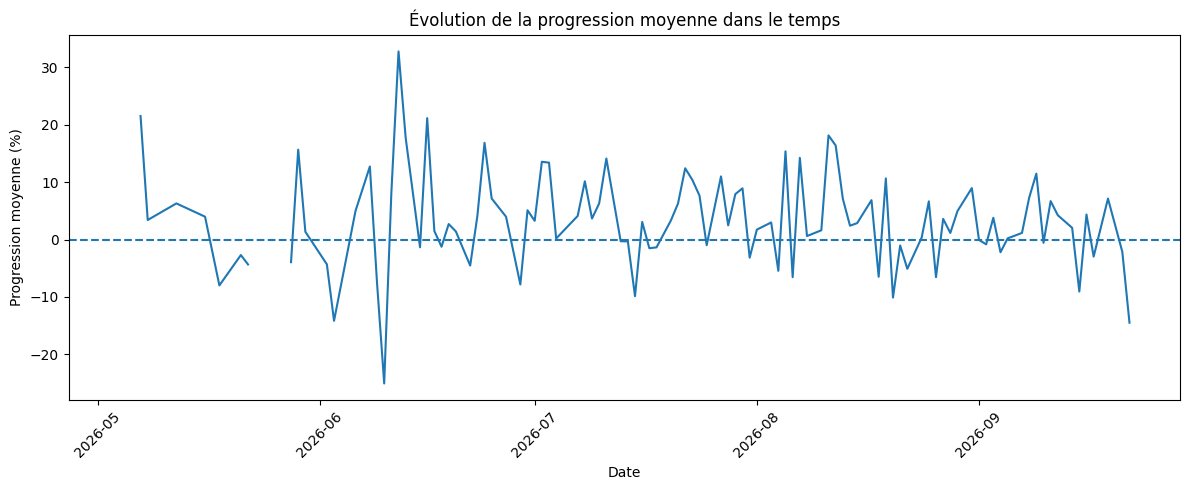

In [53]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_progression["session_day"],
    daily_progression["mean_progression"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Évolution de la progression moyenne dans le temps")
plt.xlabel("Date")
plt.ylabel("Progression moyenne (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [54]:
correlation_progression_score = (
    session_analysis[
        ["progression", "score"]
    ]
    .corr()
)

display(correlation_progression_score)

,progression,score
progression,1.000000,0.394207
score,0.394207,1.000000


In [55]:
correlation_progression_success = (
    session_analysis[
        ["progression", "success_rate"]
    ]
    .corr()
)

display(correlation_progression_success)

,progression,success_rate
progression,1.000000,0.296473
success_rate,0.296473,1.000000


In [56]:
patient_improvement_majority = (
    patient_improvement[
        patient_improvement["improvement_rate"] > 50
    ]
    .sort_values(
        "improvement_rate",
        ascending=False
    )
)

display(patient_improvement_majority)

,patient_id,first_name,last_name,sessions_with_progression,improved_sessions,declined_sessions,improvement_rate
18,19,Mohamed,Slimani,11,9,2,81.818182
4,5,Zied,Gharbi,39,26,13,66.666667
7,8,Hiba,Khelifi,12,8,4,66.666667
9,10,Maya,Trabelsi,28,18,10,64.285714
12,13,Nour,Zouari,14,9,5,64.285714
16,17,Skander,Karoui,14,9,5,64.285714
17,18,Lina,Chaouch,27,17,10,62.962963
10,11,Sirine,Ben Salah,24,15,9,62.500000
0,1,Yasmine,Bouzid,24,14,10,58.333333
5,6,Eya,Haddad,62,36,26,58.064516


In [57]:
patient_decline_majority = (
    patient_improvement[
        patient_improvement["improvement_rate"] < 50
    ]
    .sort_values(
        "improvement_rate"
    )
)

display(patient_decline_majority)

,patient_id,first_name,last_name,sessions_with_progression,improved_sessions,declined_sessions,improvement_rate
11,12,Rim,Ayari,8,3,5,37.500000
19,20,Omar,Dridi,22,9,13,40.909091
15,16,Rayan,Mansouri,14,6,8,42.857143
3,4,Malek,Hamdi,24,11,13,45.833333
14,15,Aymen,Nasri,13,6,7,46.153846


In [58]:
progression_summary = {
    "sessions_total": len(session_analysis),
    "sessions_with_progression": session_analysis["progression"].notna().sum(),
    "mean_progression": session_analysis["progression"].mean(),
    "median_progression": session_analysis["progression"].median(),
    "positive_progressions": (session_analysis["progression"] > 0).sum(),
    "negative_progressions": (session_analysis["progression"] < 0).sum(),
    "zero_progressions": (session_analysis["progression"] == 0).sum(),
    "extreme_progressions": len(extreme_progressions)
}

progression_summary

{'sessions_total': 500,
 'sessions_with_progression': np.int64(457),
 'mean_progression': np.float64(3.0039606126914657),
 'median_progression': 1.76,
 'positive_progressions': np.int64(260),
 'negative_progressions': np.int64(196),
 'zero_progressions': np.int64(1),
 'extreme_progressions': 23}

In [59]:
progression_summary_df = pd.DataFrame(
    [progression_summary]
)

display(progression_summary_df)

,sessions_total,sessions_with_progression,mean_progression,median_progression,positive_progressions,negative_progressions,zero_progressions,extreme_progressions
0,500,457,3.003961,1.76,260,196,1,23


In [60]:
dashboard_progression = session_analysis[
    [
        "id_session",
        "patient_id",
        "first_name",
        "last_name",
        "exercise_id",
        "name",
        "game_id",
        "name_game",
        "level_number",
        "session_date",
        "score",
        "success_rate",
        "repetitions",
        "duration",
        "previous_score",
        "progression",
        "progression_status"
    ]
].copy()

In [61]:
print(
    "Dimensions dashboard progression :",
    dashboard_progression.shape
)

display(
    dashboard_progression.head()
)

Dimensions dashboard progression : (500, 17)


,id_session,patient_id,first_name,last_name,exercise_id,name,game_id,name_game,level_number,session_date,score,success_rate,repetitions,duration,previous_score,progression,progression_status
0,1,1,Yasmine,Bouzid,7,Wrist Flexion and Extension,3,Wrist Wizard,3,2026-04-30 15:50:31,60.6,60.2,9,4,NaN,NaN,Première séance
1,2,1,Yasmine,Bouzid,7,Wrist Flexion and Extension,3,Wrist Wizard,3,2026-05-04 15:00:15,52.5,52.7,9,8,60.6,-13.37,Diminution
2,4,1,Yasmine,Bouzid,7,Wrist Flexion and Extension,3,Wrist Wizard,3,2026-05-07 15:00:09,63.8,68.7,10,5,52.5,21.52,Amélioration
3,6,1,Yasmine,Bouzid,7,Wrist Flexion and Extension,3,Wrist Wizard,3,2026-05-12 15:10:22,60.3,59.0,6,4,63.8,-5.49,Diminution
4,8,1,Yasmine,Bouzid,7,Wrist Flexion and Extension,3,Wrist Wizard,3,2026-05-16 10:45:20,62.7,70.3,11,9,60.3,3.98,Amélioration


In [62]:
dashboard_progression.to_csv(
    PROCESSED_PATH + "dashboard_progression.csv",
    index=False
)

patient_progression_dashboard.to_csv(
    PROCESSED_PATH + "patient_progression_dashboard.csv",
    index=False
)

exercise_progression.to_csv(
    PROCESSED_PATH + "exercise_progression.csv",
    index=False
)

game_progression.to_csv(
    PROCESSED_PATH + "game_progression.csv",
    index=False
)

level_progression.to_csv(
    PROCESSED_PATH + "level_progression.csv",
    index=False
)

progression_summary_df.to_csv(
    PROCESSED_PATH + "progression_summary.csv",
    index=False
)

In [63]:
import os

files_to_check = [
    "dashboard_progression.csv",
    "patient_progression_dashboard.csv",
    "exercise_progression.csv",
    "game_progression.csv",
    "level_progression.csv",
    "progression_summary.csv"
]

for file in files_to_check:
    path = PROCESSED_PATH + file
    
    print(
        file,
        "→",
        "OK" if os.path.exists(path) else "MANQUANT"
    )

dashboard_progression.csv → OK
patient_progression_dashboard.csv → OK
exercise_progression.csv → OK
game_progression.csv → OK
level_progression.csv → OK
progression_summary.csv → OK


In [ ]:
print("===== VÉRIFICATION FINALE =====")

print(
    "Sessions :",
    len(session_analysis)
)

print(
    "Patients :",
    session_analysis["patient_id"].nunique()
)

print(
    "Exercices :",
    session_analysis["exercise_id"].nunique()
)

print(
    "Jeux :",
    session_analysis["game_id"].nunique()
)

print(
    "Progressions disponibles :",
    session_analysis["progression"].notna().sum()
)

print(
    "Progressions manquantes :",
    session_analysis["progression"].isna().sum()
)

print(
    "Améliorations :",
    (session_analysis["progression"] > 0).sum()
)

print(
    "Diminutions :",
    (session_analysis["progression"] < 0).sum()
)

print(
    "Variations extrêmes :",
    len(extreme_progressions)
)

===== VÉRIFICATION FINALE =====
Sessions : 500
Patients : 20
Exercices : 8
Jeux : 3
Progressions disponibles : 457
Progressions manquantes : 43
Améliorations : 260
Diminutions : 196
Variations extrêmes : 23


: 

# Conclusion

L'analyse de progression permet maintenant de suivre l'évolution
des patients au cours de leurs séances.

Les analyses réalisées permettent de :

- mesurer la progression entre deux séances ;
- identifier les améliorations et les diminutions ;
- calculer la progression moyenne par patient ;
- mesurer la stabilité des performances ;
- comparer la progression entre exercices ;
- comparer la progression entre jeux ;
- analyser la progression selon le niveau ;
- identifier les variations importantes ;
- préparer les données nécessaires au dashboard thérapeute.

Les résultats produits seront utilisés dans le Notebook 07
pour préparer les données finales du dashboard.